# Imports

In [3]:
# ---------------------------------------------------------------------
# Imports
# ---------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mpl_toolkits
from mpl_toolkits.mplot3d import Axes3D  # noqa
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import re

import sys, os
from pathlib import Path

# 1) where we are right now
CWD = Path.cwd()  # /Users/.../Systematic_Energy_Trading/futures_strategies

# 2) project root = parent of current folder
PROJECT_ROOT = CWD.parent  # /Users/.../Systematic_Energy_Trading

# 3) put *project root* at the very front of sys.path
sys.path.insert(0, str(PROJECT_ROOT))

# 4) quick check
print("CWD:", CWD)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("rolling.py exists?:", (PROJECT_ROOT / "energy/strategies/rolling.py").exists())
from energy.strategies.rolling import (
    rolling_pnl,
    roll_EL,
    RollingStrategy,
    roll_EOM_NGL,
    roll_EOM_EOM_expiry,
    roll_EOM_midmonth_expiry,
    roll_EOM_dynamic_brent,
)
from energy.strategies.momentum import (
    momentum
)

from energy.strategies.value import (
    value,
    statistical_arbitrage,
    carry_value,
    momentum_with_value_filter
)

from energy.strategies.portfolios import (
    equal_weight_static, risk_parity_static, risk_parity_dynamic, mvo
)
from energy.strategies.carry import carry
from energy.analytics.metrics import metrics
from energy.preprocess.expiry_calendar import expiry_calendar
from energy.preprocess.read_data import read_data
from energy.preprocess.drop_dupes import drop_dupes

plt.style.use("seaborn-v0_8-whitegrid")

data_path = "../data/Commods.xlsx"
calendar_path = "../data/expiry_calendars.xlsx"

CWD: /Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading/CRD
PROJECT_ROOT: /Users/markbogorad/Desktop/Quant_Projects/Systematic_Energy_Trading
rolling.py exists?: True


# Set Commodities

In [4]:
# roughly set to 0.01%-0.05%

# COMMODITIES = {
#     "Propane": ("BAP", 100, 1000, 0.001),
#     "Ethane":  ("CAP", 100, 1000, 0.001),
#     "Butane":  ("DAE", 100, 1000, 0.001),
#     "WTI":     ("CL", 100, 1000, 0.01),
#     "Brent":   ("CO", 100, 1000, 0.01),
#     "ULSD":    ("HO", 100, 1000, 0.05),
#     "RBOB":    ("XB", 100, 1000, 0.02),
#     "Gasoil":  ("QS", 100, 1000, 0.02), 
#     "Natgas":  ("NG", 100, 1000, 0.001), 
# }

# No t-cost

# COMMODITIES = {
#     "Propane": ("BAP", 100, 1000, 0),
#     "Ethane":  ("CAP", 100, 1000, 0),
#     "Butane":  ("DAE", 100, 1000, 0),
#     "WTI":     ("CL", 100, 1000, 0),
#     "Brent":   ("CO", 100, 1000, 0),
#     "ULSD":    ("HO", 100, 1000, 0),
#     "RBOB":    ("XB", 100, 1000, 0),
#     "Gasoil":  ("QS", 100, 1000, 0), 
#     "Natgas":  ("NG", 100, 1000, 0), 
# }

COMMODITIES = {
    "Propane": ("BAP", 100, 1000, 0),
    "Ethane":  ("CAP", 100, 1000, 0),
    "Butane":  ("DAE", 100, 1000, 0),
    "WTI":     ("CL", 100, 1000, 0),
    "Brent":   ("CO", 100, 1000, 0),
    "ULSD":    ("HO", 100, 1000, 0),
    "RBOB":    ("XB", 100, 1000, 0),
    "Gasoil":  ("QS", 100, 1000, 0), 
    "Natgas":  ("NG", 100, 1000, 0), 
    
    # "Murban":  ("MUC", 100, 1000, 0),
    # "Dubai":   ("DAT", 100, 1000, 0),
    # "WTI Houston": ("HRT", 100, 1000, 0),
    # "WTI Midland": ("HWT", 100, 1000, 0),
    # "Dutch TTF":   ("TSB", 100, 1000, 0), #720 MwH denominated in EUR.Mwh
    # "Fuel Oil":    ("AVR", 100, 1000, 0), # USD/BBL
    # "Gulf Jet Fuel": ("GF", 100, 1000, 0), # USD/gal (42K)
    # "Eurobob":     ("IHW", 100, 1000, 0), # USD/MT, 1K MT per contract
    # "Naphtha":  ("KI", 100, 1000, 0), # USD/MT, 1K MT per contract
    # "Japan Naphtha": ("JAA", 100, 1000, 0), # USD/MT, 1K MT per contract
}

NORMALIZATION = {
    # NGLs are quoted in ¢/gal  → $/bbl  = c/gal 100 * 0.42
    "Propane": 0.42*100,
    "Ethane":  0.42*100,
    "Butane":  0.42*100,

    # Refineds are quoted in $/gal → $/bbl = $/gal * 42, 
    # since already scaling by 100 per lot, the multiplier is 0.42
    "RBOB":   0.42,
    "ULSD":   0.42,
    "Gulf Jet Fuel": 0.42,

    # Crudes already in $/bbl
    "WTI":     1.0,
    "Brent":   1.0,

    # ICE Gasoil in $/metric ton → $/bbl ≈ $/ton / 7.45
    "Gasoil":  1.0 / 7.45,   # ≈ 0.134228
    "Eurobob": 1.0 / 7.45 * 10,
    "Naphtha": 1.0 / 7.45 * 10,
    "Japan Naphtha": 1.0 / 7.45 * 10,

    # Natgas in $/MMBtu → $/bbl-equiv ≈ $/MMBtu * 5.8
    "Natgas":  5.8,
}

roll_window = 5

CLEAN_DATA = {}
all_ma_results = {}
all_carry_results = {}

# Processing Functions

In [5]:
_FCOL_PATTERN = re.compile(r"^F\d+$")

def load_prices(commodity_name: str, ticker: str, *, normalize: bool = True) -> pd.DataFrame:
    sheet_name = f"{commodity_name} ({ticker})"
    df = read_data(data_path, sheet=sheet_name)
    df = drop_dupes(df).sort_index()

    if normalize:
        scale = NORMALIZATION.get(commodity_name, 1.0)
        if scale != 1.0:
            fcols = [c for c in df.columns if _FCOL_PATTERN.match(str(c))]
            if fcols:
                df.loc[:, fcols] = df[fcols] * scale
        # remember what we did
        df.attrs["norm_scale"] = scale
    else:
        df.attrs["norm_scale"] = 1.0

    return df


def load_expiry(ticker: str) -> pd.DatetimeIndex:
    return expiry_calendar(ticker, calendar_path)


# Rolling Futures (ALL)

Rolling Propane...


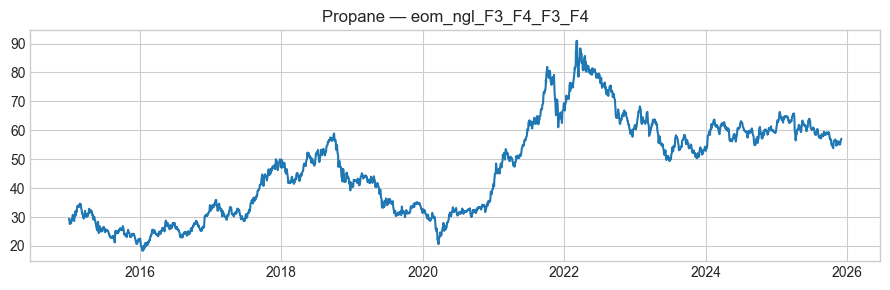

Rolling Ethane...


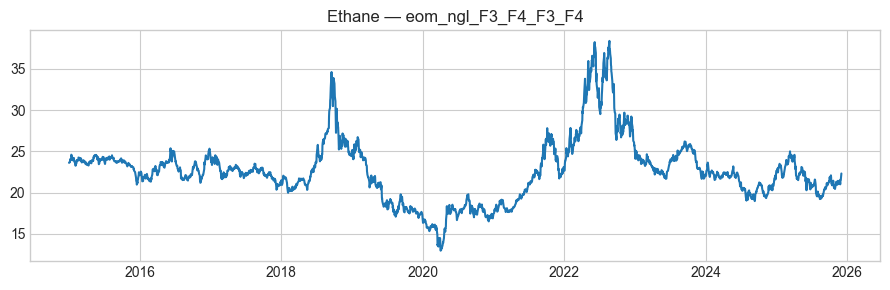

Rolling Butane...


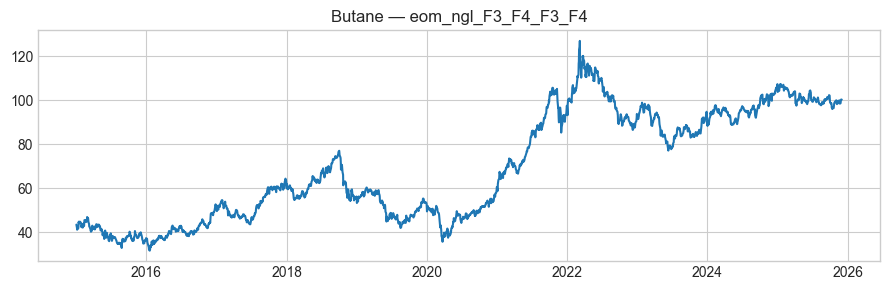

Rolling WTI...


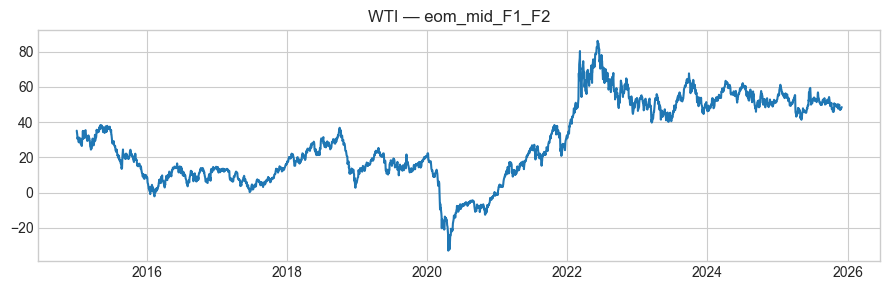

Rolling Brent...


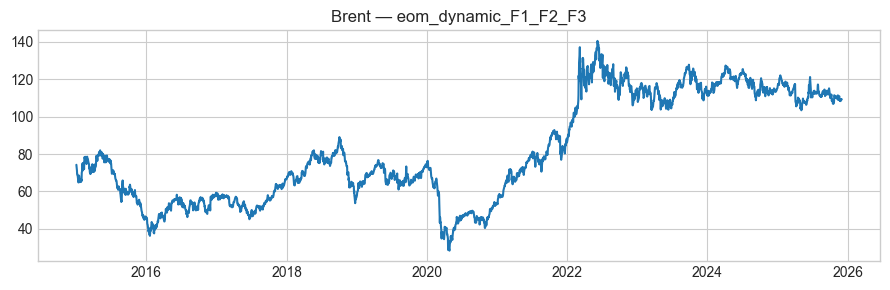

Rolling ULSD...


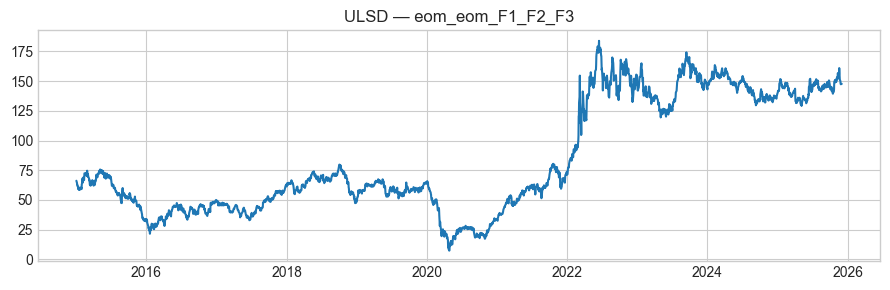

Rolling RBOB...


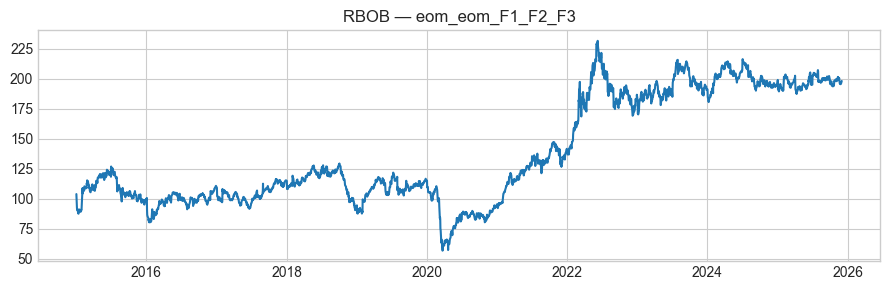

Rolling Gasoil...


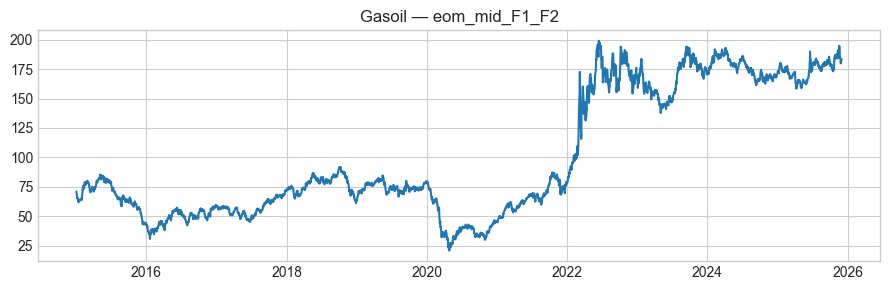

Rolling Natgas...


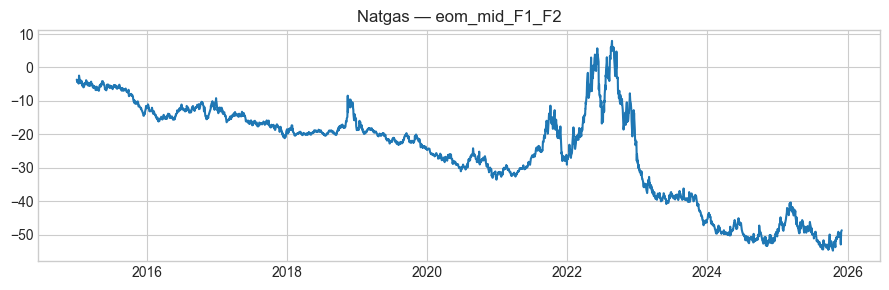

                                                       Total PnL  Total Cost  \
group             commodity roll_style                                         
Brent_dynamic     Brent     eom_dynamic_F1_F2_F3  3,407,000.0000     -0.0000   
NGL               Butane    eom_ngl_F3_F4_F3_F4   5,657,232.0000     -0.0000   
                  Ethane    eom_ngl_F3_F4_F3_F4    -139,944.0000     -0.0000   
                  Propane   eom_ngl_F3_F4_F3_F4   2,736,846.0000     -0.0000   
core_EOM_EOM      RBOB      eom_eom_F1_F2_F3      9,422,280.0000     -0.0000   
                  ULSD      eom_eom_F1_F2_F3      7,941,780.0000     -0.0000   
core_EOM_mid_F1F2 Gasoil    eom_mid_F1_F2        11,291,946.3087     -0.0000   
                  Natgas    eom_mid_F1_F2        -4,442,800.0000     -0.0000   
                  WTI       eom_mid_F1_F2         1,278,000.0000     -0.0000   

                                                  APL/unit (ann.)    CAGR  \
group             commodity roll_style    

In [6]:
HIST_START  = "2010-01-01"
TRADE_START = pd.Timestamp("2015-01-01")

BASE_ROLL_STYLES = {
    "Propane": {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},
    "Ethane":  {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},
    "Butane":  {"style": "eom_ngl",     "front_col": "F3", "next_col": "F4", "mid_col": "F3", "far_col": "F4", "group": "NGL"},

    "WTI":     {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
    "Brent":   {"style": "eom_dynamic", "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "Brent_dynamic"},
    "ULSD":    {"style": "eom_eom",     "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "core_EOM_EOM"},
    "RBOB":    {"style": "eom_eom",     "front_col": "F1", "next_col": "F2", "third_col": "F3",    "group": "core_EOM_EOM"},
    "Gasoil":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
    "Natgas":  {"style": "eom_mid",     "front_col": "F1", "next_col": "F2",                       "group": "core_EOM_mid_F1F2"},
}

def build_roll_cfg(commodity_name: str):
    base = BASE_ROLL_STYLES.get(commodity_name, {})
    style     = base.get("style", "eom_mid")
    front_col = base.get("front_col", "F1")
    next_col  = base.get("next_col",  "F2")
    mid_col   = base.get("mid_col")
    far_col   = base.get("far_col")
    third_col = base.get("third_col")
    group     = base.get("group", style)

    if "roll_style" in base:
        roll_style = base["roll_style"]
    else:
        parts = [style]
        if front_col: parts.append(front_col)
        if next_col:  parts.append(next_col)
        if mid_col:   parts.append(mid_col)
        if far_col:   parts.append(far_col)
        if third_col: parts.append(third_col)
        roll_style = "_".join(parts)

    return {
        "style": style,
        "front_col": front_col,
        "next_col": next_col,
        "mid_col": mid_col,
        "far_col": far_col,
        "third_col": third_col,
        "group": group,
        "roll_style": roll_style,
    }

ALL_LONG_ROLL     = {}
ALL_LONG_METRICS  = []
metrics_rows      = []

for commodity_name, (ticker, contracts, units, t_cost) in COMMODITIES.items():
    print(f"Rolling {commodity_name}...")

    prices = load_prices(commodity_name, ticker)
    expiry_cal = load_expiry(ticker)
    prices = prices[prices.index >= HIST_START]

    cfg = build_roll_cfg(commodity_name)

    rs = RollingStrategy(
        prices=prices,
        expiry_calendar=expiry_cal,
        front_col=cfg["front_col"],
        next_col=cfg["next_col"],
    )

    if cfg["style"] == "eom_ngl":
        equity_df = rs.equity(style="eom_ngl", t_cost=t_cost, mid_col=cfg["mid_col"], far_col=cfg["far_col"])
    elif cfg["style"] == "eom_mid":
        equity_df = rs.equity(style="eom_mid", t_cost=t_cost)
    elif cfg["style"] == "eom_dynamic":
        equity_df = rs.equity(style="eom_dynamic", t_cost=t_cost, third_col=cfg["third_col"])
    elif cfg["style"] == "eom_eom":
        equity_df = rs.equity(style="eom_eom", t_cost=t_cost, third_col=cfg["third_col"])
    else:
        raise ValueError(f"Unknown style: {cfg['style']}")

    if equity_df.empty or "equity_line" not in equity_df.columns:
        print(f"  -> WARNING: {commodity_name} equity series missing/empty, skipping.")
        continue

    first_valid = equity_df["equity_line"].first_valid_index()
    if first_valid is None:
        print(f"  -> WARNING: {commodity_name} equity_line all NaN, skipping.")
        continue

    last_date = equity_df.index.max()
    if last_date >= TRADE_START:
        effective_start = max(TRADE_START, first_valid)
    else:
        effective_start = first_valid

    equity_df = equity_df[equity_df.index >= effective_start]

    if equity_df.empty:
        print(f"  -> WARNING: {commodity_name} empty after effective clipping, skipping.")
        continue

    ALL_LONG_ROLL[commodity_name] = equity_df.copy()

    plt.figure(figsize=(9, 3))
    plt.plot(equity_df.index, equity_df["equity_line"])
    plt.title(f"{commodity_name} — {cfg['roll_style']}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    m = metrics(equity_df, contracts=contracts, units=units)
    m["commodity"]  = commodity_name
    m["group"]      = cfg["group"]
    m["roll_style"] = cfg["roll_style"]

    metrics_rows.append(m)
    ALL_LONG_METRICS.append(m)

roll_metrics_df = (
    pd.DataFrame(metrics_rows)
      .set_index(["group", "commodity", "roll_style"])
      .sort_index()
)

print(roll_metrics_df.head(40))



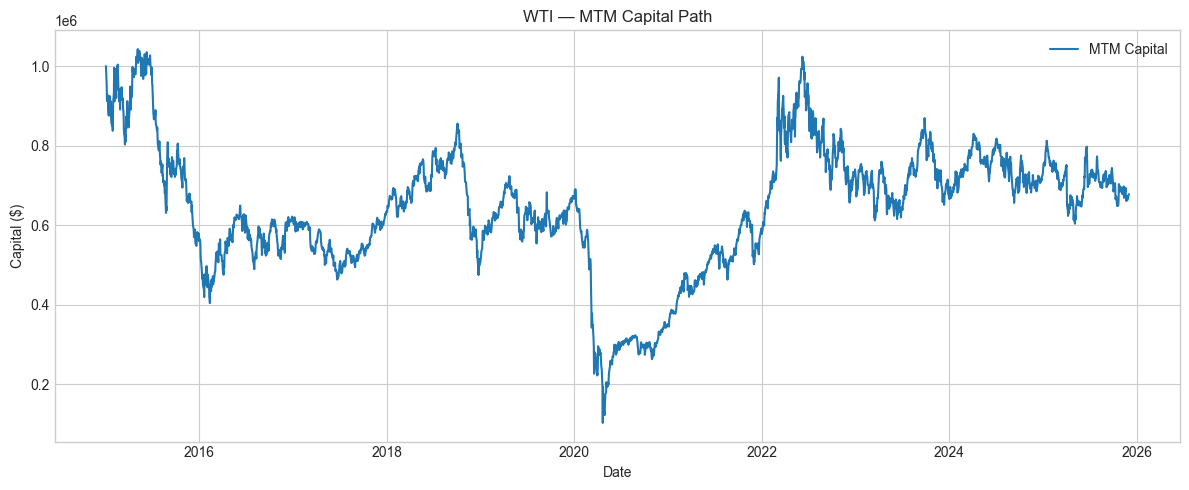

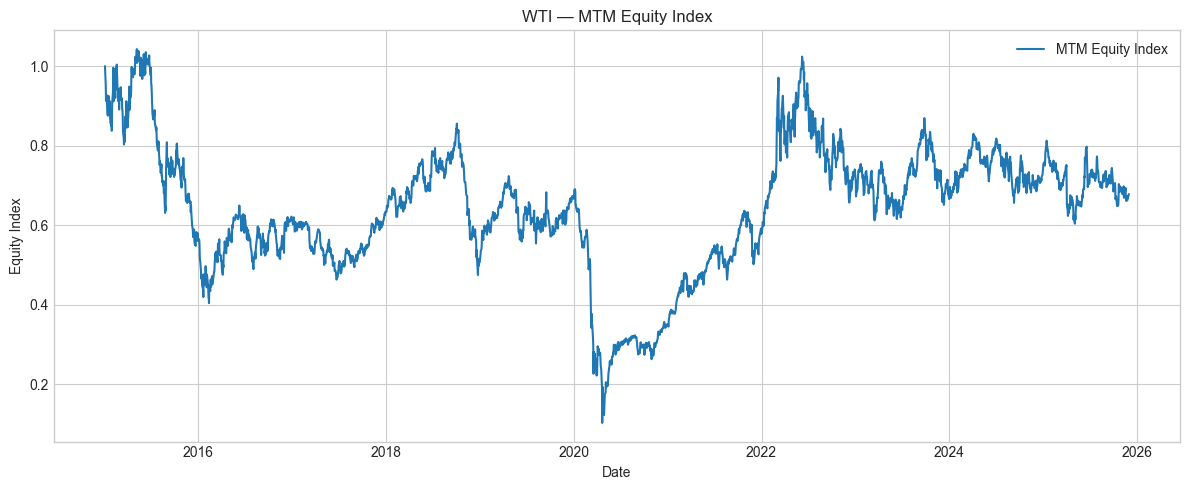

In [7]:
from energy.accounting.mtm import mtm_roll_account

commodity_name = "WTI"
ticker, contracts, units, t_cost = COMMODITIES[commodity_name]

prices = load_prices(commodity_name, ticker)
expiry_cal = load_expiry(ticker)

# Start the actual rolling / MTM account here
prices = prices[prices.index >= TRADE_START]

cfg = build_roll_cfg(commodity_name)

mtm_df = mtm_roll_account(
    prices=prices,
    expiry_calendar=expiry_cal,
    initial_capital=1_000_000,
    commodity_name=commodity_name,
    style=cfg["style"],
    roll_window=5,
    front_col=cfg["front_col"],
    next_col=cfg["next_col"],
    third_col=cfg["third_col"] if cfg["third_col"] is not None else "F3",
    mid_col=cfg["mid_col"] if cfg["mid_col"] is not None else "F3",
    far_col=cfg["far_col"] if cfg["far_col"] is not None else "F4",
    rebalance_mode="roll_only",
    include_exit_cost=False,
    round_contracts=False,
)

mtm_df[["held_contract", "held_price", "daily_pnl", "contracts_held", "dollar_pnl", "capital", "equity_index"]].head(15)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mtm_df.index, mtm_df["capital"], label="MTM Capital")
ax.set_title(f"{commodity_name} — MTM Capital Path")
ax.set_xlabel("Date")
ax.set_ylabel("Capital ($)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mtm_df.index, mtm_df["equity_index"], label="MTM Equity Index")
ax.set_title(f"{commodity_name} — MTM Equity Index")
ax.set_xlabel("Date")
ax.set_ylabel("Equity Index")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

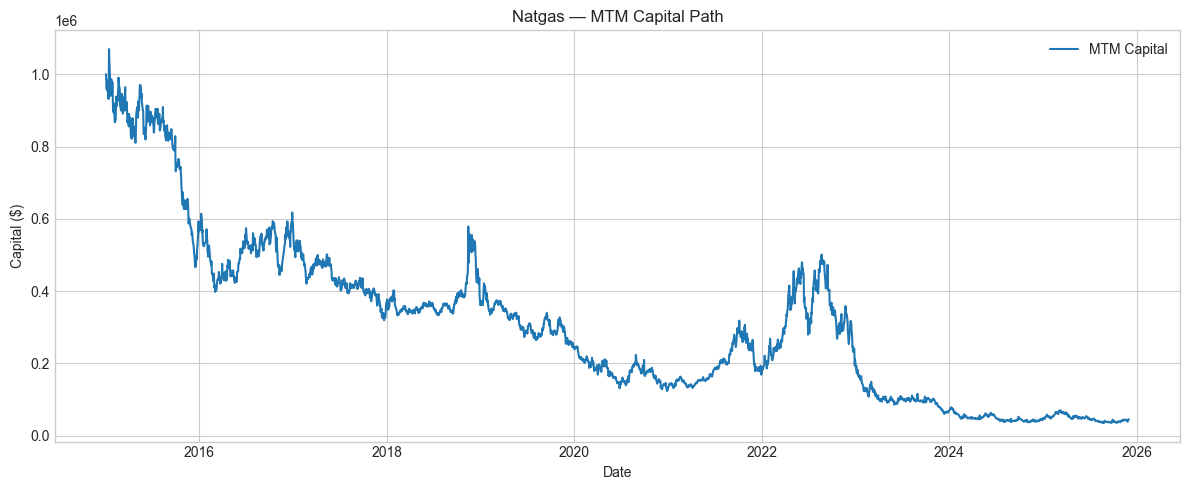

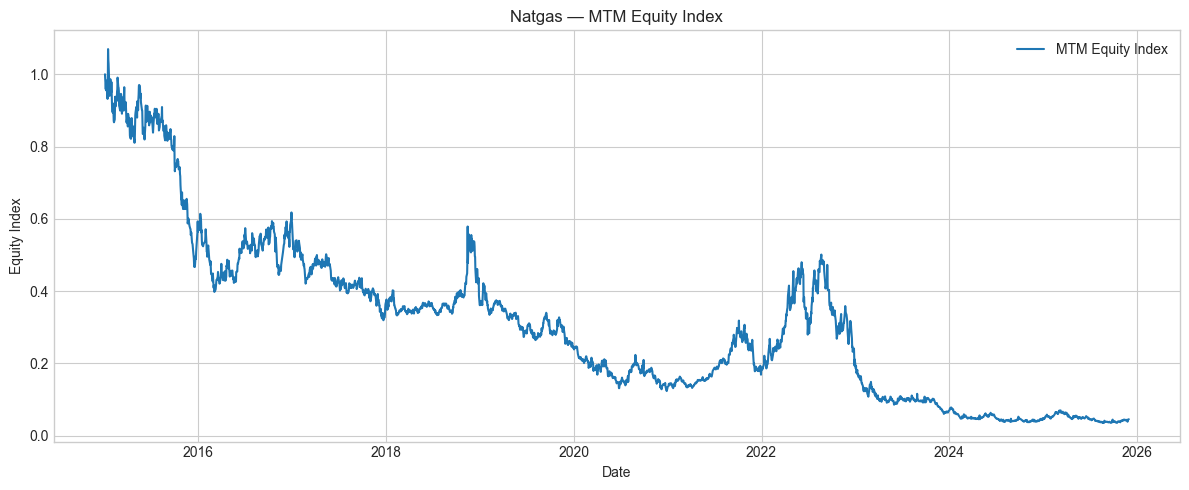

In [8]:
from energy.accounting.mtm import mtm_roll_account

commodity_name = "Natgas"
ticker, contracts, units, t_cost = COMMODITIES[commodity_name]

prices = load_prices(commodity_name, ticker)
expiry_cal = load_expiry(ticker)

# Start the actual rolling / MTM account here
prices = prices[prices.index >= TRADE_START]

cfg = build_roll_cfg(commodity_name)

mtm_df = mtm_roll_account(
    prices=prices,
    expiry_calendar=expiry_cal,
    initial_capital=1_000_000,
    commodity_name=commodity_name,
    style=cfg["style"],
    roll_window=5,
    front_col=cfg["front_col"],
    next_col=cfg["next_col"],
    third_col=cfg["third_col"] if cfg["third_col"] is not None else "F3",
    mid_col=cfg["mid_col"] if cfg["mid_col"] is not None else "F3",
    far_col=cfg["far_col"] if cfg["far_col"] is not None else "F4",
    rebalance_mode="roll_only",
    include_exit_cost=False,
    round_contracts=False,
)

mtm_df[["held_contract", "held_price", "daily_pnl", "contracts_held", "dollar_pnl", "capital", "equity_index"]].head(15)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mtm_df.index, mtm_df["capital"], label="MTM Capital")
ax.set_title(f"{commodity_name} — MTM Capital Path")
ax.set_xlabel("Date")
ax.set_ylabel("Capital ($)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mtm_df.index, mtm_df["equity_index"], label="MTM Equity Index")
ax.set_title(f"{commodity_name} — MTM Equity Index")
ax.set_xlabel("Date")
ax.set_ylabel("Equity Index")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# =========================
# Global params: Value, Carry, MA
# =========================

INIT_CAPITAL = 10_000_000

HIST_START  = "2015-01-01"                  # build signals from here
TRADE_START = pd.Timestamp("2015-01-01")    # trading sample

# VALUE (on long roll M12/M13 where available)
VALUE_MA_WINDOW   = 252 * 5       # 5y mean
VALUE_VOL_WINDOW  = 252           # kept for signature compat (ignored in band)
VALUE_EPS_BAND    = 0.15          # 15% deviation band (relative to MA)

# CARRY (timespread F4–F15, no MA band logic at strategy level)
CARRY_FRONT_COL   = "F4"
CARRY_END_COL     = "F15"

# MA (short/med/long blended momentum)
MA_PAIRS          = [(1, 5), (5, 20), (10, 60)]
MA_WEIGHTS        = None  # equal weights inside momentum()

ALL_VALUE          = {}
ALL_VALUE_METRICS  = []

ALL_CARRY          = {}
ALL_CARRY_METRICS  = []

ALL_MA_MIX         = {}
ALL_MA_MIX_METRICS = []


# =========================
# Main loop over commodities
# =========================

for commodity, cfg in BASE_ROLL_STYLES.items():
    if commodity not in COMMODITIES:
        raise KeyError(f"{commodity} missing in COMMODITIES.")

    ticker, contracts, units, t_cost = COMMODITIES[commodity]

    # --- load FULL history (normalized) ---
    prices_full = load_prices(commodity, ticker, normalize=True)
    prices_full = prices_full.loc[HIST_START:].sort_index()
    expiry_cal  = load_expiry(ticker)

    cols = prices_full.columns

    # =========================
    # BASE ROLL for CARRY & MA (per BASE_ROLL_STYLES)
    # =========================
    base_style     = cfg["style"]
    base_front_col = cfg.get("front_col", "F1")
    base_next_col  = cfg.get("next_col",  "F2")
    base_mid_col   = cfg.get("mid_col")
    base_third_col = cfg.get("third_col")

    rs_base = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=base_front_col,
        next_col=base_next_col,
    )

    if base_style == "eom_ngl":
        rolled_base = rs_base.equity(style="eom_ngl", t_cost=t_cost,
                                     mid_col=base_mid_col, far_col=cfg.get("far_col"))
    elif base_style == "eom_mid":
        rolled_base = rs_base.equity(style="eom_mid", t_cost=t_cost)
    elif base_style == "eom_dynamic":
        rolled_base = rs_base.equity(style="eom_dynamic", t_cost=t_cost,
                                     third_col=base_third_col)
    elif base_style == "eom_eom":
        rolled_base = rs_base.equity(style="eom_eom", t_cost=t_cost,
                                     third_col=base_third_col)
    else:
        raise ValueError(f"Unknown base roll style: {base_style} for {commodity}")

    rolled_base = rolled_base.sort_index()

    for col in ["daily_pnl", "t_cost", "roll_day_flag"]:
        if col not in rolled_base.columns:
            raise ValueError(f"'{col}' missing in rolled_base for {commodity}")

    # =========================
    # LONG ROLL for VALUE (M12/M13 where possible)
    # =========================
    if "F12" in cols and "F13" in cols:
        roll_front_val = "F12"
        roll_next_val  = "F13"
        style_tag_val  = "M12-M13_EOM"
    elif "F12" in cols:
        roll_front_val = "F12"
        roll_next_val  = "F12"
        style_tag_val  = "F12_only_EOM"
    elif "F13" in cols:
        roll_front_val = "F13"
        roll_next_val  = "F13"
        style_tag_val  = "F13_only_EOM"
    else:
        roll_front_val = base_front_col
        roll_next_val  = base_next_col
        style_tag_val  = f"FALLBACK_{roll_front_val}_{roll_next_val}_EOM"

    rs_val = RollingStrategy(
        prices=prices_full,
        expiry_calendar=expiry_cal,
        front_col=roll_front_val,
        next_col=roll_next_val,
    )

    rolled_val = rs_val.equity(style="eom_mid", t_cost=t_cost).sort_index()

    for col in ["daily_pnl", "t_cost", "roll_day_flag"]:
        if col not in rolled_val.columns:
            raise ValueError(f"'{col}' missing in rolled_val for {commodity}")

    # =========================
    # VALUE STRATEGY
    # =========================

    if "F12" in cols:
        anchor_col = "F12"
    elif "F13" in cols:
        anchor_col = "F13"
    else:
        anchor_col = roll_front_val
        print(f"[WARN] {commodity}: using {anchor_col} as value anchor (no F12/F13).")

    prices_full["VAL_ANCHOR"] = prices_full[anchor_col].astype(float)

    val_full = value(
        prices=prices_full,
        rolled_df=rolled_val,
        front_col="VAL_ANCHOR",
        long_ma=VALUE_MA_WINDOW,
        vol_window=VALUE_VOL_WINDOW,
        epsilon_factor=VALUE_EPS_BAND,
        t_cost=t_cost,
    )

    val_df = val_full.loc[TRADE_START:].copy()
    if val_df.empty:
        print(f"[WARN] {commodity}: VALUE series empty after TRADE_START clipping, skipping VALUE.")
    else:
        exposure = contracts * units
        val_df["pnl_usd"]        = val_df["net_pnl"] * exposure
        val_df["cum_pnl_usd"]    = val_df["pnl_usd"].cumsum()
        val_df["equity_account"] = INIT_CAPITAL + val_df["cum_pnl_usd"]

        acc       = val_df["equity_account"]
        ret_ratio = acc / acc.shift(1)
        mask      = (acc > 0) & (acc.shift(1) > 0)

        val_df["log_ret"]           = np.nan
        val_df.loc[mask, "log_ret"] = np.log(ret_ratio[mask])
        val_df["cum_log_ret"]       = val_df["log_ret"].cumsum()
        val_df["log_equity_norm"]   = val_df["cum_log_ret"]
        val_df["equity_norm"]       = val_df["equity_account"] / INIT_CAPITAL

        val_df["commodity"]   = commodity
        val_df["ticker"]      = ticker
        val_df["style"]       = style_tag_val
        val_df["ma_window"]   = VALUE_MA_WINDOW
        val_df["vol_window"]  = VALUE_VOL_WINDOW
        val_df["eps_band"]    = VALUE_EPS_BAND

        ALL_VALUE[commodity] = val_df

        m = metrics(val_df, contracts=contracts, units=units)
        if isinstance(m, pd.Series):
            m = m.to_dict()
        m["commodity"]  = commodity
        m["style"]      = style_tag_val
        m["ma_window"]  = VALUE_MA_WINDOW
        m["vol_window"] = VALUE_VOL_WINDOW
        m["eps_band"]   = VALUE_EPS_BAND
        ALL_VALUE_METRICS.append(m)

    # =========================
    # CARRY STRATEGY (using BASE roll)
    # =========================

    if (CARRY_FRONT_COL in cols) and (CARRY_END_COL in cols):
        carry_full = carry_value(
            prices=prices_full,
            rolled_df=rolled_base,
            front_col=CARRY_FRONT_COL,
            end_col=CARRY_END_COL,
            t_cost=t_cost,
        )

        carry_df = carry_full.loc[TRADE_START:].copy()
        if carry_df.empty:
            print(f"[WARN] {commodity}: CARRY series empty after TRADE_START clipping, skipping CARRY.")
        else:
            exposure = contracts * units
            carry_df["pnl_usd"]        = carry_df["net_pnl"] * exposure
            carry_df["cum_pnl_usd"]    = carry_df["pnl_usd"].cumsum()
            carry_df["equity_account"] = INIT_CAPITAL + carry_df["cum_pnl_usd"]

            acc       = carry_df["equity_account"]
            ret_ratio = acc / acc.shift(1)
            mask      = (acc > 0) & (acc.shift(1) > 0)

            carry_df["log_ret"]           = np.nan
            carry_df.loc[mask, "log_ret"] = np.log(ret_ratio[mask])
            carry_df["cum_log_ret"]       = carry_df["log_ret"].cumsum()
            carry_df["log_equity_norm"]   = carry_df["cum_log_ret"]
            carry_df["equity_norm"]       = carry_df["equity_account"] / INIT_CAPITAL

            carry_df["commodity"]   = commodity
            carry_df["ticker"]      = ticker
            carry_df["style"]       = f"CARRY_{CARRY_FRONT_COL}_{CARRY_END_COL}"
            carry_df["front_col"]   = CARRY_FRONT_COL
            carry_df["end_col"]     = CARRY_END_COL

            ALL_CARRY[commodity] = carry_df

            m = metrics(carry_df, contracts=contracts, units=units)
            if isinstance(m, pd.Series):
                m = m.to_dict()
            m["commodity"]  = commodity
            m["style"]      = f"CARRY_{CARRY_FRONT_COL}_{CARRY_END_COL}"
            m["front_col"]  = CARRY_FRONT_COL
            m["end_col"]    = CARRY_END_COL
            ALL_CARRY_METRICS.append(m)
    else:
        print(f"[WARN] {commodity}: missing {CARRY_FRONT_COL}/{CARRY_END_COL}, skipping CARRY.")

    # =========================
    # MA (Momentum) STRATEGY (using BASE roll)
    # =========================

    ma_full = momentum(
        prices=prices_full,
        rolled_df=rolled_base,
        ma_pairs=MA_PAIRS,
        weights=MA_WEIGHTS,
        t_cost=t_cost,
    )

    ma_df = ma_full.loc[TRADE_START:].copy()
    if ma_df.empty:
        print(f"[WARN] {commodity}: MA series empty after TRADE_START clipping, skipping MA.")
    else:
        exposure = contracts * units
        ma_df["pnl_usd"]        = ma_df["net_pnl"] * exposure
        ma_df["cum_pnl_usd"]    = ma_df["pnl_usd"].cumsum()
        ma_df["equity_account"] = INIT_CAPITAL + ma_df["cum_pnl_usd"]

        acc       = ma_df["equity_account"]
        ret_ratio = acc / acc.shift(1)
        mask      = (acc > 0) & (acc.shift(1) > 0)

        ma_df["log_ret"]           = np.nan
        ma_df.loc[mask, "log_ret"] = np.log(ret_ratio[mask])
        ma_df["cum_log_ret"]       = ma_df["log_ret"].cumsum()
        ma_df["log_equity_norm"]   = ma_df["cum_log_ret"]
        ma_df["equity_norm"]       = ma_df["equity_account"] / INIT_CAPITAL

        ma_df["commodity"]   = commodity
        ma_df["ticker"]      = ticker
        ma_df["style"]       = "MA_blend"
        ma_df["ma_pairs"]    = str(MA_PAIRS)

        ALL_MA_MIX[commodity] = ma_df

        m = metrics(ma_df, contracts=contracts, units=units)
        if isinstance(m, pd.Series):
            m = m.to_dict()
        m["commodity"]  = commodity
        m["style"]      = "MA_blend"
        m["ma_pairs"]   = str(MA_PAIRS)
        ALL_MA_MIX_METRICS.append(m)

# =========================
# Metrics tables by commodity / strategy
# =========================

VALUE_METRICS = pd.DataFrame(ALL_VALUE_METRICS).set_index("commodity")
CARRY_METRICS = pd.DataFrame(ALL_CARRY_METRICS).set_index("commodity")
MA_METRICS    = pd.DataFrame(ALL_MA_MIX_METRICS).set_index("commodity")

print("VALUE_METRICS:")
print(VALUE_METRICS)

print("\nCARRY_METRICS:")
print(CARRY_METRICS)

print("\nMA_METRICS:")
print(MA_METRICS)

# =========================
# Metrics tables by commodity / strategy
# =========================

VALUE_METRICS = pd.DataFrame(ALL_VALUE_METRICS).set_index("commodity")
CARRY_METRICS = pd.DataFrame(ALL_CARRY_METRICS).set_index("commodity")
MA_METRICS    = pd.DataFrame(ALL_MA_MIX_METRICS).set_index("commodity")

print("VALUE_METRICS:")
print(VALUE_METRICS)

print("\nCARRY_METRICS:")
print(CARRY_METRICS)

print("\nMA_METRICS:")
print(MA_METRICS)


# =========================
# Build Standardized Metrics Panel
# =========================

# columns that are metadata / config (NOT performance metrics)
META_COLS = {
    "style", "ma_pairs", "ma_window", "vol_window", "eps_band",
    "front_col", "end_col", "ticker"
}

def strip_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Drop non-performance columns so we don't get garbage rows in the panel."""
    return df[[c for c in df.columns if c not in META_COLS]]

# helper: slice a dict of equity DataFrames by date range and recompute metrics
def slice_by_period(df_dict, start, end):
    out = {}
    for com, df in df_dict.items():
        if "equity_account" not in df.columns:
            continue
        sliced = df.loc[start:end]
        if sliced.empty:
            continue
        m = metrics(sliced)
        if isinstance(m, pd.Series):
            m = m.to_dict()
        out[com] = m
    if not out:
        return pd.DataFrame()
    return pd.DataFrame(out).T  # commodities as rows

# ---------- FULL SAMPLE (use already-computed metrics, but strip meta) ----------
mom_full = strip_meta(MA_METRICS.copy())       # index: commodity, cols: perf metrics only
car_full = strip_meta(CARRY_METRICS.copy())
val_full = strip_meta(VALUE_METRICS.copy())

# ---------- SUB PERIODS ----------
PER1 = ("2015-01-01", "2022-01-01")
PER2 = ("2022-01-01", "2025-01-01")

mom_15_22 = strip_meta(slice_by_period(ALL_MA_MIX,  *PER1))
car_15_22 = strip_meta(slice_by_period(ALL_CARRY,   *PER1))
val_15_22 = strip_meta(slice_by_period(ALL_VALUE,   *PER1))

mom_22_25 = strip_meta(slice_by_period(ALL_MA_MIX,  *PER2))
car_22_25 = strip_meta(slice_by_period(ALL_CARRY,   *PER2))
val_22_25 = strip_meta(slice_by_period(ALL_VALUE,   *PER2))

# ---------- Long form helper ----------
def metrics_to_long(df, strategy, sample_label):
    """
    df: metrics DataFrame (index=commodity, columns=metric names)
    returns long-form DF with index (commodity, metric) and columns:
      ['value', 'Strategy', 'Sample']
    """
    if df.empty:
        return pd.DataFrame(
            columns=["value", "Strategy", "Sample"],
            index=pd.MultiIndex.from_arrays([[], []], names=["commodity", "metric"])
        )

    tmp = df.copy()
    tmp["commodity"] = tmp.index
    tmp = tmp.set_index("commodity")

    long = tmp.stack().to_frame("value")  # index: (commodity, metric)
    long.index.set_names(["commodity", "metric"], inplace=True)
    long["Strategy"] = strategy
    long["Sample"]   = sample_label
    return long

# ---------- Build long panel ----------
pieces = []

# Full sample
pieces.append(metrics_to_long(mom_full,   "MOM", "Full"))
pieces.append(metrics_to_long(car_full,   "CAR", "Full"))
pieces.append(metrics_to_long(val_full,   "VAL", "Full"))

# 2015–2022
pieces.append(metrics_to_long(mom_15_22,  "MOM", "2015-2022"))
pieces.append(metrics_to_long(car_15_22,  "CAR", "2015-2022"))
pieces.append(metrics_to_long(val_15_22,  "VAL", "2015-2022"))

# 2022–2025
pieces.append(metrics_to_long(mom_22_25,  "MOM", "2022-2025"))
pieces.append(metrics_to_long(car_22_25,  "CAR", "2022-2025"))
pieces.append(metrics_to_long(val_22_25,  "VAL", "2022-2025"))

long_panel = pd.concat(pieces, axis=0)

# =========================
# Assemble into Final Panel
# =========================

# index: (commodity, metric)
# columns: MultiIndex (Sample, Strategy)
panel_df = (
    long_panel
    .set_index(["Sample", "Strategy"], append=True)["value"]
    .unstack(["Sample", "Strategy"])
)

# Optional: order levels as [2015-2022, 2022-2025, Full] and [MOM, CAR, VAL]
panel_df = panel_df.reindex(
    columns=pd.MultiIndex.from_product(
        [["2015-2022", "2022-2025", "Full"], ["MOM", "CAR", "VAL"]],
        names=["Sample", "Strategy"],
    )
)

display(panel_df)


VALUE_METRICS:
               Total PnL  Total Cost  APL/unit (ann.)    CAGR  Std Dev (ann.)  \
commodity                                                                       
Propane    -387,492.0000     -0.0000          -0.3548 -0.0036          6.8886   
Ethane      238,392.0000     -0.0000           0.2183  0.0022          2.8519   
Butane      -41,790.0000     -0.0000          -0.0383 -0.0004          8.0418   
WTI         491,000.0000     -0.0000           0.4496  0.0044         12.6735   
Brent     1,737,000.0000     -0.0000           1.5906  0.0148         12.9472   
ULSD        643,020.0000     -0.0000           0.5888  0.0057         15.7276   
RBOB       -163,380.0000     -0.0000          -0.1496 -0.0015         17.8176   
Gasoil     -580,536.9128     -0.0000          -0.5316 -0.0055         15.4097   
Natgas      644,380.0000     -0.0000           0.5901  0.0057          5.5346   

           Sharpe  Drawdown     RoD   Years        style  ma_window  \
commodity             

Sample                     2015-2022                             2022-2025  \
Strategy                         MOM          CAR         VAL          MOM   
commodity metric                                                             
Brent     APL/unit (ann.)     1.5486      -8.3871      1.5629     -16.0426   
          CAGR                0.0148      -0.1187      0.0149      -0.1918   
          Drawdown           -0.3768      -0.6604     -0.1832      -0.6511   
          RoD                 4.1099     -12.6992      8.5310     -24.6407   
          Sharpe              0.0787      -0.4590      0.1574      -0.4880   
...                              ...          ...         ...          ...   
WTI       Sharpe              0.0333      -0.2971     -0.0460      -0.3620   
          Std Dev (ann.)     20.2077      19.0494      9.7848      33.0093   
          Total Cost         -0.0000      -0.0000     -0.0000      -0.0000   
          Total PnL       4,710.0000 -39,620.0000 -3,150.0000 -35,780.0000   
          Years               7.0000       7.0000      7.0000       2.9945   

Sample                                                      Full  \
Strategy                          CAR        VAL             MOM   
commodity metric                                                   
Brent     APL/unit (ann.)      0.7080     0.6779         -4.9283   
          CAGR                 0.0127     0.0122         -0.0683   
          Drawdown            -0.5354    -0.3347         -0.7190   
          RoD                  1.3222     2.0257         -6.8546   
          Sharpe               0.0215     0.0349         -0.2051   
...                               ...        ...             ...   
WTI       Sharpe               0.4920     0.0439         -0.1099   
          Std Dev (ann.)      33.0020    18.9598         24.4218   
          Total Cost          -0.0000    -0.0000         -0.0000   
          Total PnL       48,620.0000 2,490.0000 -2,931,000.0000   
          Years                2.9945     2.9945         10.9205   

Sample                                                 
Strategy                             CAR          VAL  
commodity metric                                       
Brent     APL/unit (ann.)        -4.9970       1.5906  
          CAGR                   -0.0697       0.0148  
          Drawdown               -1.1280      -0.3251  
          RoD                    -4.4299       4.8932  
          Sharpe                 -0.2144       0.1229  
...                                  ...          ...  
WTI       Sharpe                  0.0532       0.0355  
          Std Dev (ann.)         23.8198      12.6735  
          Total Cost             -0.0000      -0.0000  
          Total PnL       1,384,000.0000 491,000.0000  
          Years                  10.9205      10.9205  

[81 rows x 9 columns]